Concept: Memory

Technique/function/object using for this memory concept: CheckPoint

It is called when we are compiling the graph. After every node runs, Langgraph automatically calls the checkpointer to save a snapshot of teh current state.


In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image

class CounterState(TypedDict):
    count: int
    messages: list

def increment(state: CounterState) -> CounterState:
    new_count = state["count"] + 1
    log_message = state["messages"] + [f"incremented to {new_count}"]
    return {"count":new_count, "messages": log_message}

builder = StateGraph(CounterState)

builder.add_node("increment", increment)

builder.add_edge(START, "increment")
builder.add_edge("increment", END)

memory = MemorySaver()

graph = builder.compile(checkpointer=memory)


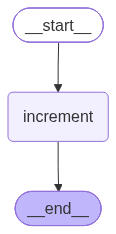

In [4]:

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


In [15]:
response1 = graph.invoke(
    {
        "count": 3,
        "messages": ["About to increment"]
    },
    config={"configurable": {"thread_id": "1"}}
)

print(response1)

{'count': 4, 'messages': ['About to increment', 'incremented to 4']}


In [ ]:
response2 = graph.invoke(
    None, #even if the input is None, we will get the previous executed result from the memory.
    config={"configurable": {"thread_id": "1"}}
)

print(response2)

{'count': 7, 'messages': ['About to increment', 'incremented to 7']}
